# Module 5 — Thai Text Analytics
**MADT6004 Wrap-Up · Brew Lab BKK case**

Khun Ploy: *"The numbers say one branch is fine. My gut says it's not. What are customers actually saying — and where is it worst?"*

What you'll do:
1. Load the **Thai + English review corpus**.
2. Tokenize with **PyThaiNLP**, remove stopwords.
3. Build a **bi-gram network graph** of frequent word pairs.
4. Use **POS tagging** to extract entities (nouns) and descriptors (adjectives), then visualize the **entity ↔ adjective network**.
5. Run **topic modeling** (LDA) and surface complaint themes.
6. Cross-tab topics × branch × time → find the **Thonglor leading-indicator**: a branch where complaint volume is rising before ratings drop.

## 1. Setup

PyThaiNLP installation:
```bash
pip install pythainlp
```

In [ ]:
# Bootstrap — pulls the dataset and installs deps when the notebook is opened in Colab.
# Local Jupyter runs from .../notebooks/ and finds ../data/brewlab.db directly, so this is a no-op.
import os
if not os.path.exists("../data/brewlab.db"):
    if not os.path.exists("MADT6004"):
        os.system("git clone -q https://github.com/thanachart/MADT6004.git")
    os.system("pip install -q -r 'MADT6004/Integrated Data Analytics Exercise/requirements.txt'")
    os.chdir("MADT6004/Integrated Data Analytics Exercise/notebooks")

In [ ]:
import sqlite3
import warnings
import re
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 100

import matplotlib
import matplotlib.font_manager as fm
import os, tempfile, urllib.request

# Download Noto Sans Thai if missing — Colab and most Windows machines don't ship with it.
font_path = os.path.join(tempfile.gettempdir(), "NotoSansThai.ttf")
if not os.path.exists(font_path):
    try:
        urllib.request.urlretrieve(
            "https://github.com/google/fonts/raw/main/ofl/notosansthai/NotoSansThai%5Bwdth,wght%5D.ttf",
            font_path,
        )
    except Exception:
        pass
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    thai_family = fm.FontProperties(fname=font_path).get_name()
    matplotlib.rcParams['font.family'] = [thai_family, 'DejaVu Sans']
else:
    matplotlib.rcParams['font.family'] = ['DejaVu Sans']

from pythainlp.tokenize import word_tokenize
from pythainlp.corpus import thai_stopwords
from pythainlp.tag import pos_tag

THAI_STOPS = set(thai_stopwords())
# Add common stop-ish words for our domain
DOMAIN_STOPS = {'ร้าน','สาขา','ที่','นี้','มาก','แต่','ก็','ค่ะ','ครับ',' ','','-','/','(',')','.', ',', ':'}
ALL_STOPS = THAI_STOPS | DOMAIN_STOPS

EN_STOPS = {'the','a','an','at','of','to','in','for','is','was','it','this','that','and','or','but','my','i','very','too','so'}

conn = sqlite3.connect("../data/brewlab.db")
reviews = pd.read_sql("SELECT * FROM reviews", conn)
reviews['review_date'] = pd.to_datetime(reviews['review_date'])
print(f"Total reviews: {len(reviews)}")
print(reviews.head(3)[['review_id','branch_id','rating','sentiment_label','text']])

## 2. Tokenize and clean

In [2]:
def tokenize_thai_en(text):
    """Mixed Thai + English tokenizer with cleaning."""
    if not isinstance(text, str):
        return []
    # PyThaiNLP handles Thai segmentation; for English mixed in, it produces tokens too
    tokens = word_tokenize(text, engine='newmm')
    out = []
    for tok in tokens:
        tok = tok.strip().lower()
        if not tok or tok in ALL_STOPS or tok in EN_STOPS:
            continue
        if re.fullmatch(r'[\d\W_]+', tok):  # all digits/punct
            continue
        if len(tok) == 1 and not re.match(r'[ก-๙]', tok):
            continue
        out.append(tok)
    return out

reviews['tokens'] = reviews['text'].apply(tokenize_thai_en)
print("Sample tokenization:")
for i in range(3):
    print(f"  text   : {reviews['text'].iloc[i]}")
    print(f"  tokens : {reviews['tokens'].iloc[i]}")
    print()

Sample tokenization:
  text   : ร้านAriบรรยากาศดีมาก Ham & Cheese Toastอร่อย พนักงานบริการดี
  tokens : ['ari', 'บรรยากาศ', 'ดีมาก', 'ham', 'cheese', 'toast', 'อร่อย', 'พนักงานบริการ', 'ดี']

  text   : นั่งทำงานสบาย wifi เร็ว Tote Bagคุ้มราคา
  tokens : ['นั่ง', 'ทำงาน', 'wifi', 'tote', 'bag', 'คุ้ม', 'ราคา']

  text   : ชอบIced Latteที่นี่ หอม กลมกล่อม จะกลับมาอีกแน่นอน
  tokens : ['ชอบ', 'iced', 'latte', 'ที่นี่', 'หอม', 'กลมกล่อม', 'กลับมา', 'แน่นอน']



## 3. Word frequency

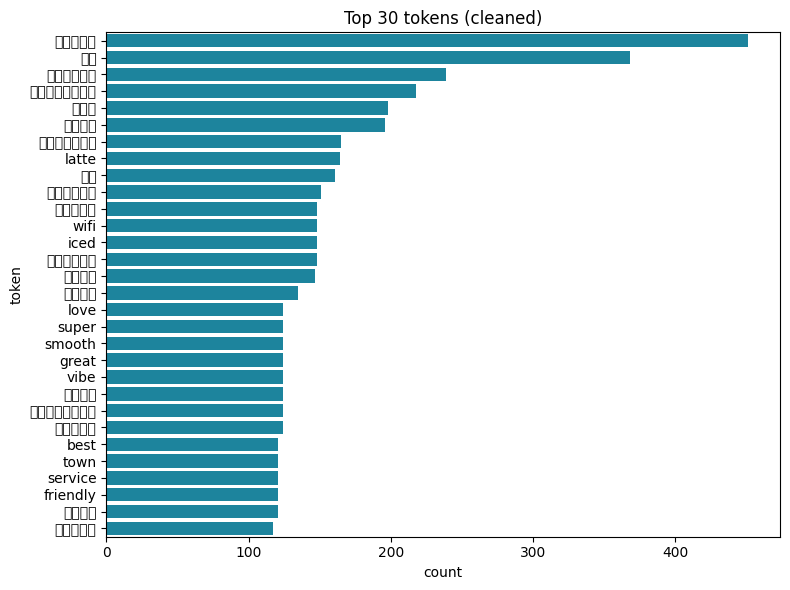

In [3]:
all_tokens = [t for toks in reviews['tokens'] for t in toks]
freq = Counter(all_tokens)
top = pd.DataFrame(freq.most_common(30), columns=['token','count'])
fig, ax = plt.subplots(figsize=(8,6))
sns.barplot(data=top, y='token', x='count', color='#0891B2', ax=ax)
ax.set_title("Top 30 tokens (cleaned)")
plt.tight_layout(); plt.show()

## 4. Bi-gram network graph

In [4]:
def bigrams(tokens):
    return list(zip(tokens[:-1], tokens[1:]))

bg = Counter()
for toks in reviews['tokens']:
    bg.update(bigrams(toks))

# Filter for meaningful pairs
top_bg = [(a, b, c) for (a, b), c in bg.most_common() if c >= 8 and a != b]
print(f"Top bi-grams (count >= 8): {len(top_bg)}")
bg_df = pd.DataFrame(top_bg[:30], columns=['word1','word2','count'])
print(bg_df.head(15))

Top bi-grams (count >= 8): 199
       word1     word2  count
0         รอ      นาที    135
1      super    smooth    124
2     smooth     great    124
3      great      vibe    124
4       เค้ก    ที่นี่    124
5     ที่นี่     อร่อย    124
6      อร่อย  โดยเฉพาะ    124
7       town   service    121
8    service  friendly    121
9      สะอาด   ที่นั่ง    117
10    รสชาติ        ดี    117
11    ที่นี่       หอม    115
12       หอม  กลมกล่อม    115
13  กลมกล่อม    กลับมา    115
14    กลับมา    แน่นอน    115


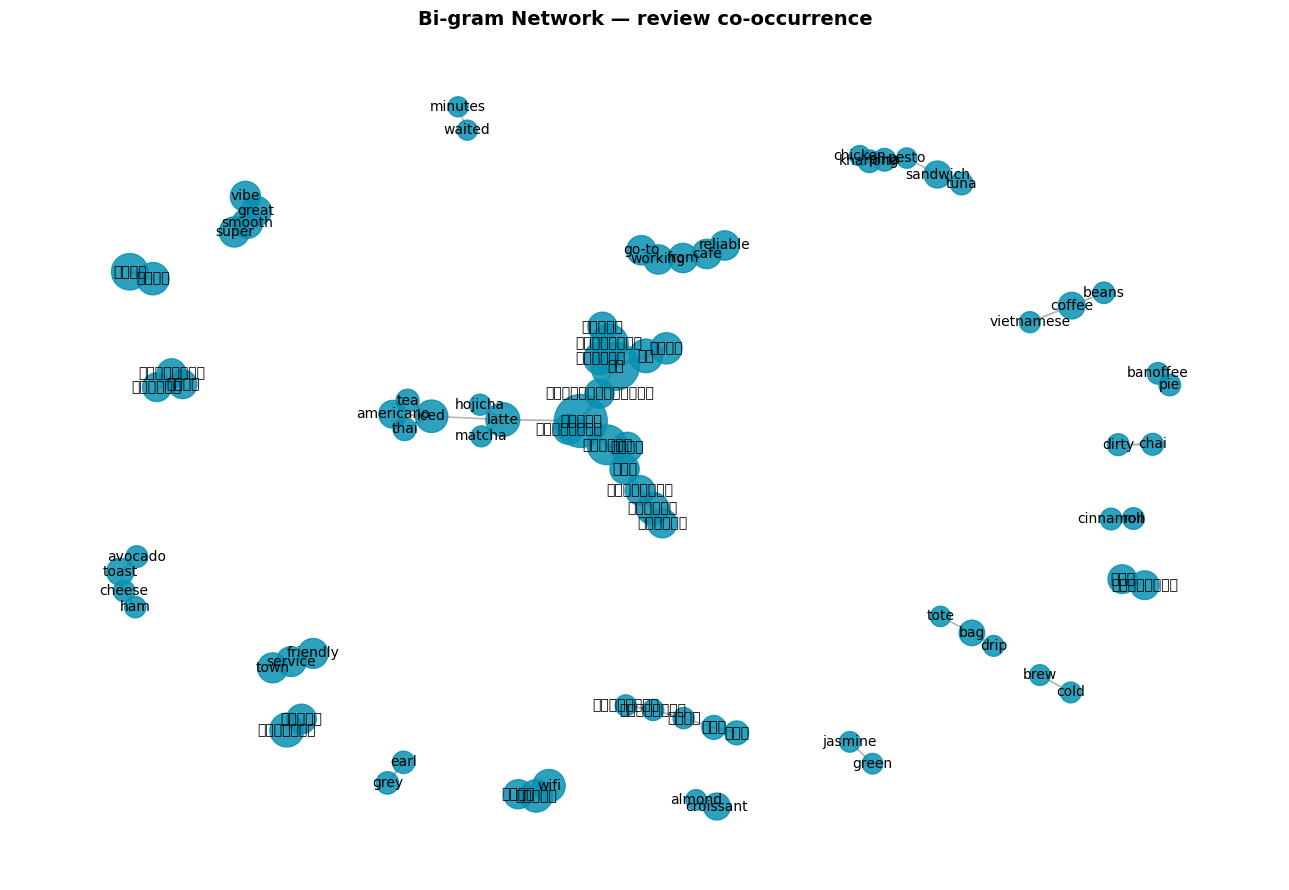

In [5]:
# Build network
G = nx.Graph()
for w1, w2, c in top_bg[:60]:
    if G.has_edge(w1, w2):
        G[w1][w2]['weight'] += c
    else:
        G.add_edge(w1, w2, weight=c)

fig, ax = plt.subplots(figsize=(13,9))
pos = nx.spring_layout(G, k=0.6, iterations=80, seed=42)
node_size = [freq[n]*3 + 100 for n in G.nodes()]
edges = list(G.edges(data=True))
weights = [d['weight'] for _,_,d in edges]
maxw = max(weights) if weights else 1
nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color='#0891B2', alpha=0.85, ax=ax)
nx.draw_networkx_edges(G, pos, width=[w/maxw*4 for w in weights], alpha=0.4, edge_color='#374151', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=10)
ax.set_title("Bi-gram Network — review co-occurrence", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout(); plt.show()

## 5. POS tagging — extract entities (nouns) and adjectives

PyThaiNLP's POS tagger uses the **ORCHID tagset**:
- `NCMN`, `NPRP`, `NTTL` — nouns (common, proper, title) → **entities**
- `VATT`, `ADVN`, `ADJX` — adjective-like → **descriptors**

We extract noun-adjective co-occurrences within each review and visualize the network.

(Optional: PyThaiNLP also has a NER engine — `from pythainlp.tag.named_entity import NER` — but it requires a corpus download. POS-based extraction is the dependable path.)

In [6]:
NOUN_TAGS = {'NCMN','NPRP','NTTL','NLBL','NONM'}
ADJ_TAGS  = {'VATT','ADJX','ADVN','ADVI','ADVP'}

def extract_noun_adj(tokens):
    if not tokens:
        return [], []
    tagged = pos_tag(tokens)
    nouns = [w for w, t in tagged if t in NOUN_TAGS]
    adjs  = [w for w, t in tagged if t in ADJ_TAGS]
    return nouns, adjs

reviews[['nouns','adjs']] = reviews['tokens'].apply(
    lambda x: pd.Series(extract_noun_adj(x), index=['nouns','adjs']))

# Build noun–adjective co-occurrence (within the same review)
na_pairs = Counter()
for _, row in reviews.iterrows():
    for n in row['nouns']:
        for a in row['adjs']:
            na_pairs[(n, a)] += 1

print(f"Unique noun-adjective pairs: {len(na_pairs)}")
print("Top 20 entity ↔ adjective pairs:")
for (n, a), c in na_pairs.most_common(20):
    print(f"  {n:20} ↔ {a:15} {c}")

Unique noun-adjective pairs: 353
Top 20 entity ↔ adjective pairs:
  บรรยากาศ             ↔ ดี              218
  เค้ก                 ↔ โดยเฉพาะ        124
  สะอาด                ↔ ดี              117
  ที่นั่ง              ↔ ดี              117
  รสชาติ               ↔ ดี              117
  ที่นี่               ↔ แน่นอน          115
  หอม                  ↔ แน่นอน          115
  กลมกล่อม             ↔ แน่นอน          115
  บรรยากาศ             ↔ ดีมาก           113
  อร่อย                ↔ ดีมาก           113
  อร่อย                ↔ ดี              113
  พนักงานบริการ        ↔ ดีมาก           113
  พนักงานบริการ        ↔ ดี              113
  ชอบ                  ↔ แน่นอน          113
  wifi                 ↔ เย็น            35
  latte                ↔ ดี              34
  ekkamai              ↔ ดี              34
  รสชาติ               ↔ เหมือนเดิม      34
  พนักงาน              ↔ ดี              33
  พนักงาน              ↔ กลับมา          33


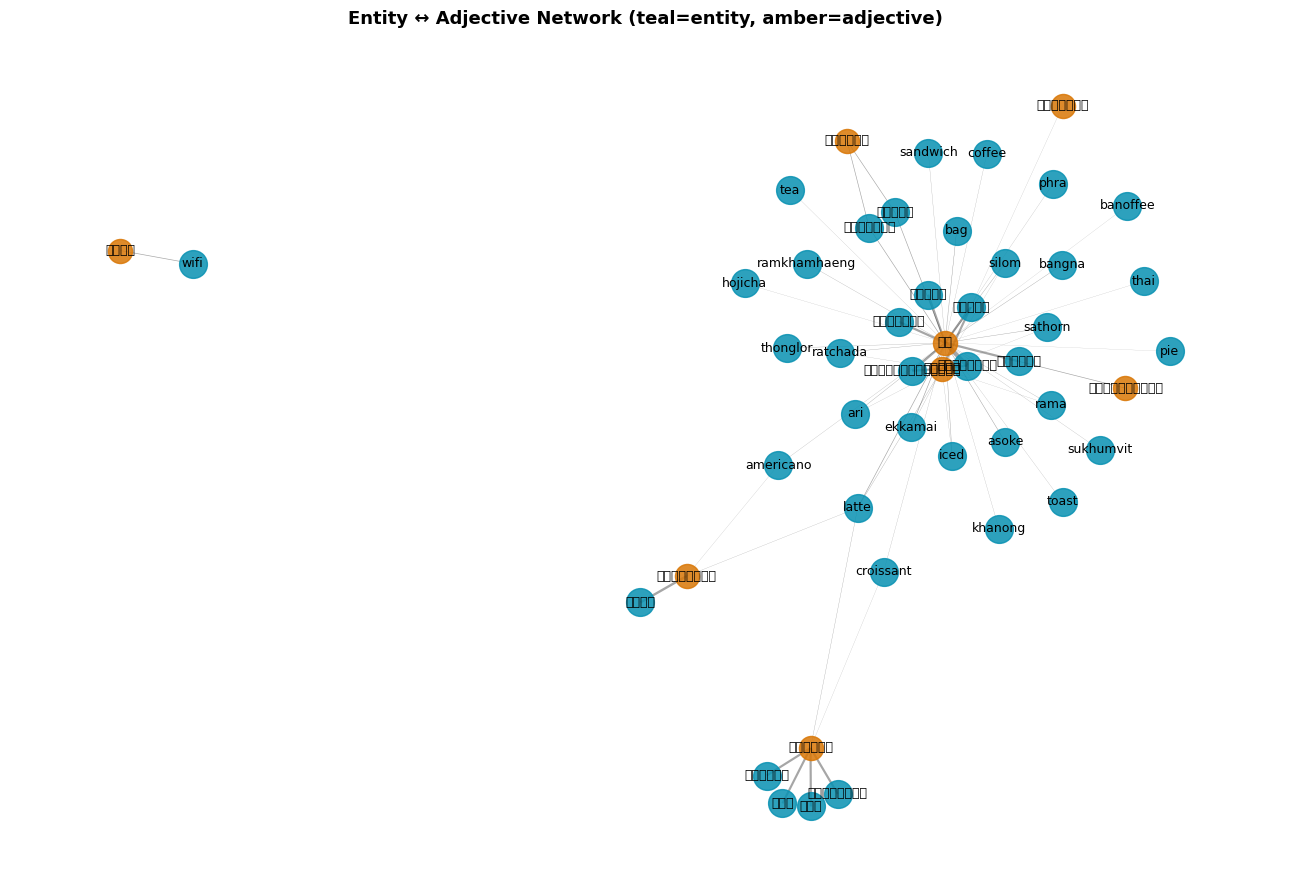

In [7]:
# Network: nouns (entities) ↔ adjectives (descriptors)
G2 = nx.Graph()
for (n, a), c in na_pairs.most_common(60):
    G2.add_node(n, kind='entity')
    G2.add_node(a, kind='adj')
    G2.add_edge(n, a, weight=c)

fig, ax = plt.subplots(figsize=(13, 9))
pos = nx.spring_layout(G2, k=0.7, iterations=80, seed=42)
ent = [n for n, d in G2.nodes(data=True) if d['kind']=='entity']
adj = [n for n, d in G2.nodes(data=True) if d['kind']=='adj']
nx.draw_networkx_nodes(G2, pos, nodelist=ent, node_color='#0891B2',
                       node_size=400, alpha=0.85, ax=ax)
nx.draw_networkx_nodes(G2, pos, nodelist=adj, node_color='#D97706',
                       node_size=300, alpha=0.85, ax=ax)
weights = [d['weight'] for _,_,d in G2.edges(data=True)]
maxw = max(weights) if weights else 1
nx.draw_networkx_edges(G2, pos, width=[w/maxw*3 for w in weights],
                       alpha=0.35, ax=ax)
nx.draw_networkx_labels(G2, pos, font_size=9)
ax.set_title("Entity ↔ Adjective Network (teal=entity, amber=adjective)",
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout(); plt.show()

## 6. Topic modeling — LDA

Latent Dirichlet Allocation finds groups of words that co-occur. We tune `n_topics` to surface the latent themes.

In [8]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Build a "joined" token document for sklearn
docs = reviews['tokens'].apply(lambda toks: ' '.join(toks)).tolist()

cv = CountVectorizer(min_df=5, max_df=0.6, token_pattern=r'\S+')
X = cv.fit_transform(docs)
vocab = cv.get_feature_names_out()
print(f"Vocab size: {len(vocab)}, doc-term matrix: {X.shape}")

K = 5
lda = LatentDirichletAllocation(n_components=K, random_state=42, max_iter=20, learning_method='online')
doc_topic = lda.fit_transform(X)

print(f"\nTopics ({K}):")
for k, comp in enumerate(lda.components_):
    top_words = [vocab[i] for i in comp.argsort()[-12:][::-1]]
    print(f"  Topic {k}: {' / '.join(top_words)}")

Vocab size: 146, doc-term matrix: (1835, 146)



Topics (5):
  Topic 0: ดี / อร่อย / บรรยากาศ / รอ / ที่นั่ง / รสชาติ / นาที / iced / โปรด / สะอาด / ดีมาก / พนักงานบริการ
  Topic 1: ที่นี่ / กลับมา / อร่อย / โดยเฉพาะ / เค้ก / แนะนำ / กลมกล่อม / หอม / แน่นอน / service / best / town
  Topic 2: wifi / ทำงาน / คุ้ม / ราคา / นั่ง / sandwich / grey / earl / dirty / chai / cinnamon / roll
  Topic 3: บาริสต้า / อธิบาย / ใจดี / ฟัง / ประทับใจ / coffee / ชอบ / อีกแล้ว / ราคา / beans / brew / cold
  Topic 4: great / love / vibe / smooth / super / working / reliable / cafe / from / go-to / banoffee / pie


## 7. Topic × branch × time — the Thonglor leading indicator

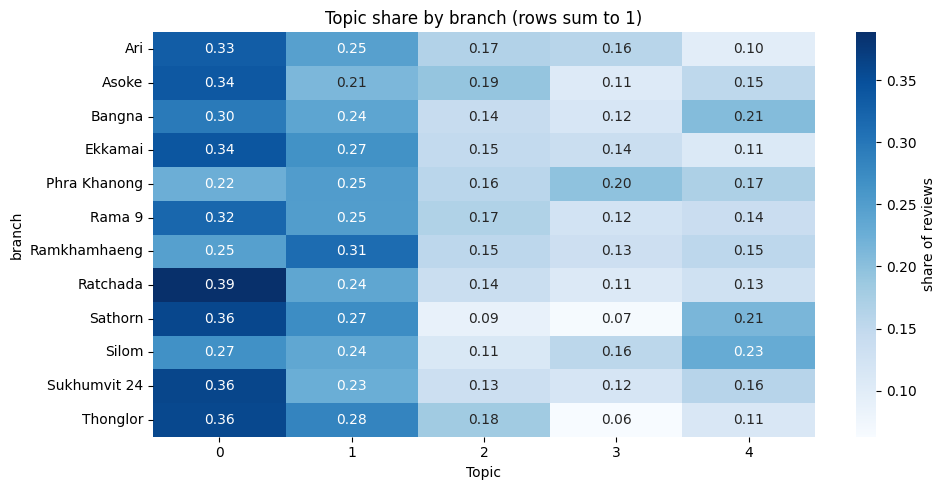

In [9]:
# Assign each review its dominant topic
reviews['topic'] = doc_topic.argmax(axis=1)
reviews['month'] = reviews['review_date'].dt.to_period('M').astype(str)

branches = pd.read_sql("SELECT branch_id, name AS branch FROM branches", conn)
reviews_b = reviews.merge(branches, on='branch_id')

# Heatmap: branch × topic
ct = pd.crosstab(reviews_b['branch'], reviews_b['topic'], normalize='index')
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues", ax=ax,
            cbar_kws={'label':'share of reviews'})
ax.set_title("Topic share by branch (rows sum to 1)")
ax.set_xlabel("Topic")
plt.tight_layout(); plt.show()

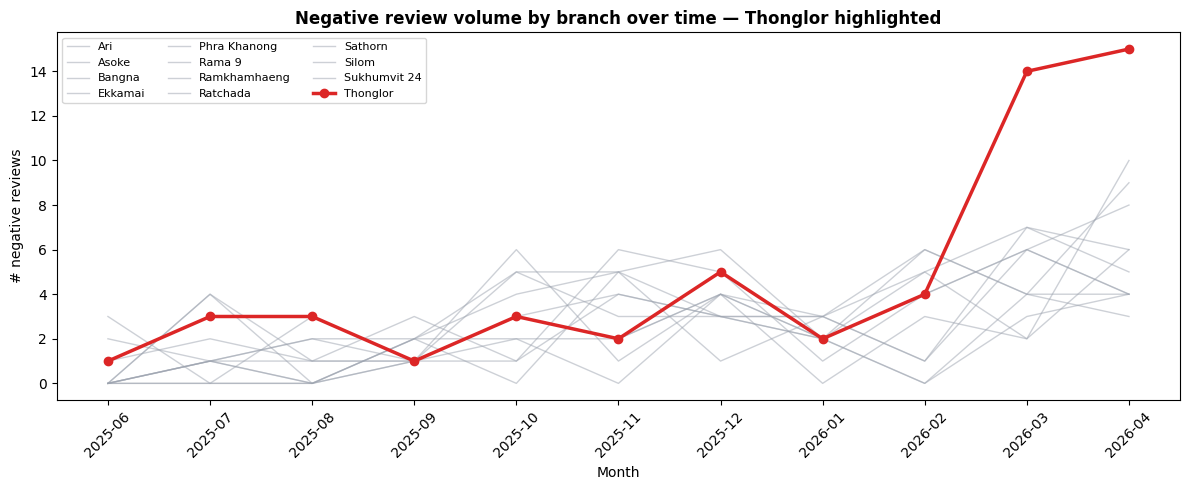

In [10]:
# Negative sentiment volume by branch over time
neg = reviews_b[reviews_b['sentiment_label'] == 'negative']
neg_pivot = neg.groupby(['month','branch']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
for col in neg_pivot.columns:
    is_thonglor = col == 'Thonglor'
    ax.plot(neg_pivot.index, neg_pivot[col],
            marker='o' if is_thonglor else None,
            lw=2.5 if is_thonglor else 1,
            color='#DC2626' if is_thonglor else '#9CA3AF',
            label=col, alpha=1 if is_thonglor else 0.5)
ax.set_title("Negative review volume by branch over time — Thonglor highlighted",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Month"); ax.set_ylabel("# negative reviews")
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper left', fontsize=8, ncol=3)
plt.tight_layout(); plt.show()

In [11]:
# Compare avg rating vs negative review share for Thonglor in last 6 weeks vs prior
thg = reviews_b[reviews_b['branch']=='Thonglor'].copy()
recent = thg[thg['review_date'] >= '2026-03-19']
prior  = thg[thg['review_date'] <  '2026-03-19']
print(f"Thonglor — recent (last 6w): rating={recent['rating'].mean():.2f}, "
      f"neg share={(recent['sentiment_label']=='negative').mean()*100:.0f}%, n={len(recent)}")
print(f"Thonglor — prior        : rating={prior['rating'].mean():.2f}, "
      f"neg share={(prior['sentiment_label']=='negative').mean()*100:.0f}%, n={len(prior)}")
print()
print("→ Negative volume rising sharply, but average rating only modestly affected.")
print("  This is a leading indicator: complaint volume moves before star rating.")

Thonglor — recent (last 6w): rating=2.73, neg share=63%, n=41
Thonglor — prior        : rating=3.88, neg share=23%, n=118

→ Negative volume rising sharply, but average rating only modestly affected.
  This is a leading indicator: complaint volume moves before star rating.


## 8. Sentiment score back into Module 3

The sentiment score (or topic share) per customer can be added as a feature to Module 3's churn / response classifier. Watch the AUC move.

In [12]:
# Compute customer-level sentiment summary
cust_sent = reviews.groupby('customer_id').agg(
    n_reviews=('review_id','size'),
    pct_negative=('sentiment_label', lambda s: (s=='negative').mean()),
    avg_rating=('rating','mean')
).reset_index()
print("Customer-level sentiment features (sample):")
print(cust_sent.head())
print(f"\n{len(cust_sent)} customers have written reviews. "
      f"This becomes a join key for Module 3's feature table.")

Customer-level sentiment features (sample):
   customer_id  n_reviews  pct_negative  avg_rating
0            3          1           0.0         5.0
1            4          1           0.0         3.0
2           13          1           0.0         5.0
3           31          1           1.0         3.0
4           40          1           0.0         4.0

1512 customers have written reviews. This becomes a join key for Module 3's feature table.


## 9. Discussion prompts

1. The bi-gram network surfaces **what people say together**. The entity-adjective network surfaces **what they call things**. Which is more actionable for ops?
2. The Thonglor pattern is the kind of **leading indicator** that quantitative dashboards miss. How would you institutionalize this — sentiment monitoring as an early-warning system?
3. POS-based "NER" is good enough for branches and product names. When would you invest in a real NER model?
4. Topic modeling assigns one dominant topic per review. What's lost? How would you handle reviews that span multiple complaints?

## End of integrated exercise

Looking back across all five modules, you've gone from raw transactions to a defensible decision system:

- **Module 1** told us *what's actually true* about revenue drivers (with FDR control).
- **Module 2** told us *what's coming* (per SKU per branch).
- **Module 3** told us *who to target* (with proper sampling for class imbalance).
- **Module 4** told us *how customers cluster and what to recommend*.
- **Module 5** told us *what they're saying* — and surfaced a leading indicator the numbers missed.

The loop closes when Module 5's sentiment score becomes a feature in Module 3, and Module 4's segments become targeting filters. **This is what real practice looks like.**